<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/lectures/machine_learning/mle_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Regresión

<div align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/3/3a/Linear_regression.svg" width="500"/>
</div>

> En la sección de Inferencia trabajamos la regresión lineal desde un enfoque estadístico: coeficientes, p-values, supuestos. Aquí el enfoque es distinto: nos interesa **construir modelos que predigan bien en datos nuevos**. Usamos `scikit-learn` como herramienta principal y comparamos varios modelos sobre los mismos datos.

---

## Librerías

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)



## 1. El Problema de Regresión

Un problema de **regresión** consiste en predecir una variable continua $y$ a partir de un conjunto de features $X$.

El flujo estándar en scikit-learn es siempre el mismo, independientemente del modelo:

```
1. Dividir datos en train/test
2. Instanciar el modelo
3. Entrenar: modelo.fit(X_train, y_train)
4. Predecir: modelo.predict(X_test)
5. Evaluar con métricas
```

<!-- IMAGEN SUGERIDA: diagrama del flujo train/test split → fit → predict → evaluate, mostrando que el modelo nunca ve el test set durante el entrenamiento. -->

In [9]:
# Dataset: precio de viviendas
np.random.seed(42)
n = 300

superficie   = np.random.uniform(40, 220, n)
habitaciones = np.random.randint(1, 6, n).astype(float)
distancia    = np.random.uniform(1, 35, n)
antiguedad   = np.random.uniform(0, 45, n)
piso         = np.random.randint(1, 15, n).astype(float)

precio = (2_000_000
          + 38_000  * superficie
          + 900_000 * habitaciones
          - 130_000 * distancia
          - 55_000  * antiguedad
          + 200_000 * piso
          + np.random.normal(0, 2_500_000, n))

df = pd.DataFrame({
    'precio':       precio,
    'superficie':   superficie,
    'habitaciones': habitaciones,
    'distancia':    distancia,
    'antiguedad':   antiguedad,
    'piso':         piso
})

print(f"Dataset: {df.shape[0]} observaciones, {df.shape[1]-1} features")
print(df.describe().round(0))

Dataset: 300 observaciones, 5 features
           precio  superficie  habitaciones  distancia  antiguedad   piso
count       300.0       300.0         300.0      300.0       300.0  300.0
mean    7874561.0       129.0           3.0       18.0        23.0    8.0
std     3831299.0        53.0           1.0       10.0        13.0    4.0
min    -3828454.0        41.0           1.0        1.0         0.0    1.0
25%     5119827.0        83.0           2.0        9.0        13.0    4.0
50%     7950001.0       132.0           3.0       19.0        24.0    8.0
75%    10607512.0       176.0           4.0       26.0        35.0   12.0
max    17657187.0       218.0           5.0       35.0        45.0   14.0


In [10]:
# Separar features y target
X = df.drop(columns='precio')
y = df['precio']

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} observaciones")
print(f"Test:  {X_test.shape[0]} observaciones")

Train: 240 observaciones
Test:  60 observaciones


---

## 2. Métricas de Evaluación

Antes de entrenar cualquier modelo, es importante entender cómo vamos a medir su rendimiento.


| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum \lvert y_i - \hat{y}_i \rvert$ | Error promedio en las mismas unidades que $y$. Fácil de interpretar. |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penaliza más los errores grandes. Sensible a outliers. |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | Proporción de varianza explicada. Entre 0 y 1 (puede ser negativo si el modelo es muy malo). |


> 💡 No existe una métrica universal. MAE es preferible cuando queremos comunicar el error en términos del negocio. RMSE es útil cuando los errores grandes son especialmente costosos. R² sirve para comparar modelos entre sí.

In [11]:
def evaluar_modelo(nombre, y_true, y_pred):
    """Imprime MAE, RMSE y R² para un conjunto de predicciones."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    print(f"{'Modelo':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
    print("-" * 60)
    print(f"{nombre:<25} {mae:>12,.0f} {rmse:>12,.0f} {r2:>8.4f}")
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

---

## 3. Regresión Lineal con scikit-learn

Ya conocemos el modelo desde la sección de inferencia. Aquí lo usamos con `scikit-learn`, que tiene una API más orientada a predicción que a inferencia.

In [12]:
def evaluar_modelo(nombre, y_true, y_pred):
    """Imprime MAE, RMSE y R² para un conjunto de predicciones."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{'Modelo':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
    print("-" * 60)
    print(f"{nombre:<25} {mae:>12,.0f} {rmse:>12,.0f} {r2:>8.4f}")
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

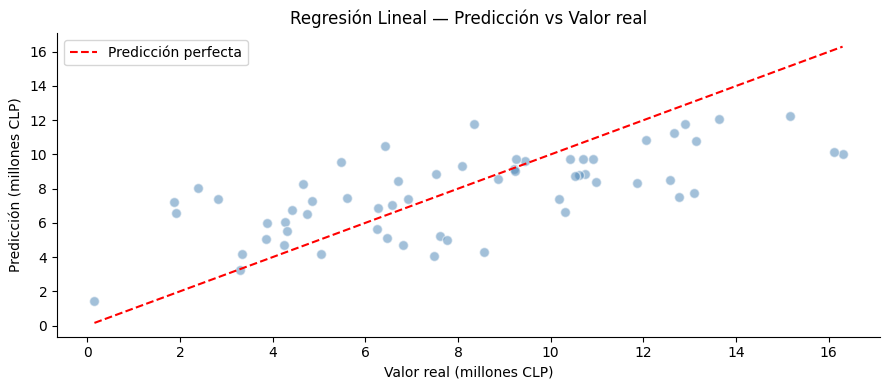

In [13]:
# Visualización: predicción vs valor real
fig, ax = plt.subplots()
ax.scatter(y_test/1e6, y_pred_lr/1e6, alpha=0.5, color='steelblue',
           edgecolor='white', s=50)
lim = [min(y_test.min(), y_pred_lr.min())/1e6,
       max(y_test.max(), y_pred_lr.max())/1e6]
ax.plot(lim, lim, 'r--', lw=1.5, label='Predicción perfecta')
ax.set_title('Regresión Lineal — Predicción vs Valor real')
ax.set_xlabel('Valor real (millones CLP)')
ax.set_ylabel('Predicción (millones CLP)')
ax.legend()
plt.tight_layout()
plt.show()

---

## 4. Regularización: Ridge y Lasso

La regularización agrega una penalización a los coeficientes grandes durante el entrenamiento. Esto reduce el overfitting, especialmente cuando hay muchas features o multicolinealidad.

| Modelo | Penalización | Efecto |
|---|---|---|
| **Ridge** ($L_2$) | $\lambda \sum \beta_j^2$ | Reduce la magnitud de todos los coeficientes, pero los mantiene distintos de cero |
| **Lasso** ($L_1$) | $\lambda \sum \lvert \beta_j \rvert$ | Puede llevar coeficientes exactamente a cero → selección de variables implícita |

El parámetro $\lambda$ (`alpha` en scikit-learn) controla la intensidad de la penalización: $\lambda = 0$ es equivalente a regresión lineal sin regularización.

<!-- IMAGEN SUGERIDA: diagrama comparando las regiones de restricción de Ridge (círculo) y Lasso (rombo), mostrando por qué Lasso produce coeficientes exactamente cero. -->

In [14]:
# Ridge y Lasso requieren escalar las features primero
# Usamos Pipeline para encadenar scaler + modelo

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso(alpha=10_000))
])

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

resultados.append(evaluar_modelo('Ridge (α=1)', y_test, y_pred_ridge))
print()
resultados.append(evaluar_modelo('Lasso (α=10k)', y_test, y_pred_lasso))

Modelo                             MAE         RMSE       R²
------------------------------------------------------------
Ridge (α=1)                  2,269,176    2,809,115   0.4477

Modelo                             MAE         RMSE       R²
------------------------------------------------------------
Lasso (α=10k)                2,271,211    2,810,849   0.4470


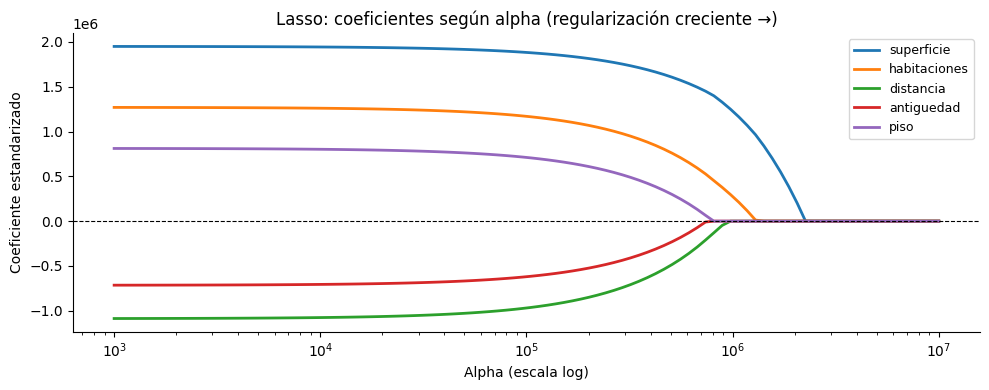

In [15]:
# Efecto de alpha sobre los coeficientes de Lasso
alphas = np.logspace(3, 7, 100)
coefs = []

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

for a in alphas:
    m = Lasso(alpha=a, max_iter=10000)
    m.fit(X_train_scaled, y_train)
    coefs.append(m.coef_)

coefs = np.array(coefs)

fig, ax = plt.subplots(figsize=(10, 4))
for i, col in enumerate(X.columns):
    ax.plot(alphas, coefs[:, i], lw=2, label=col)
ax.set_xscale('log')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('Lasso: coeficientes según alpha (regularización creciente →)')
ax.set_xlabel('Alpha (escala log)')
ax.set_ylabel('Coeficiente estandarizado')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



## 5. Árbol de Decisión para Regresión

Un árbol de decisión divide el espacio de features en regiones rectangulares y predice el promedio de $y$ en cada región. No asume ninguna forma funcional (lineal o de otro tipo), lo que lo hace flexible pero propenso a overfitting.

El parámetro más importante es `max_depth`: a mayor profundidad, más complejo el modelo y mayor riesgo de memorizar el train set.

<!-- IMAGEN SUGERIDA: árbol de decisión pequeño (profundidad 3) con nodos mostrando la pregunta de división, número de muestras y valor predicho en cada hoja. -->

In [16]:
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

resultados.append(evaluar_modelo('Árbol (depth=5)', y_test, y_pred_tree))

Modelo                             MAE         RMSE       R²
------------------------------------------------------------
Árbol (depth=5)              3,109,279    3,733,845   0.0241


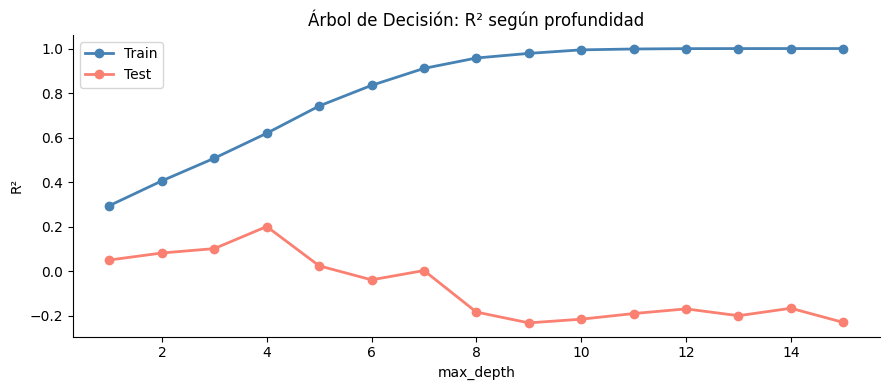

→ Cuando train sube pero test baja: el modelo está sobreajustando (overfitting)


In [17]:
# Efecto de max_depth sobre train vs test
profundidades = range(1, 16)
r2_train, r2_test = [], []

for d in profundidades:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    r2_train.append(r2_score(y_train, m.predict(X_train)))
    r2_test.append(r2_score(y_test,  m.predict(X_test)))

fig, ax = plt.subplots()
ax.plot(profundidades, r2_train, 'o-', color='steelblue', lw=2, label='Train')
ax.plot(profundidades, r2_test,  'o-', color='salmon',    lw=2, label='Test')
ax.set_title('Árbol de Decisión: R² según profundidad')
ax.set_xlabel('max_depth')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

print("→ Cuando train sube pero test baja: el modelo está sobreajustando (overfitting)")

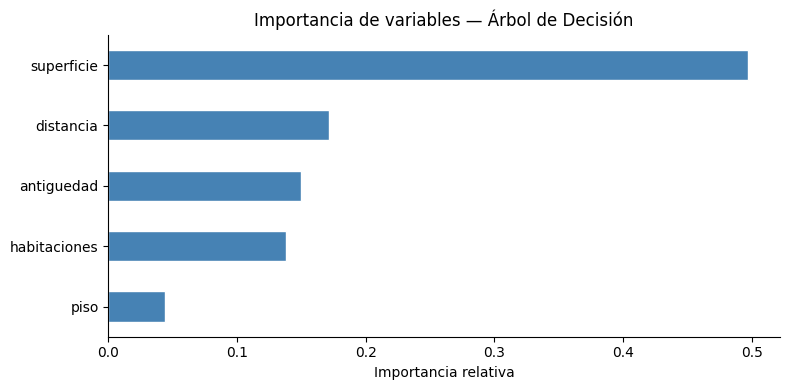

In [18]:
# Importancia de variables
importancias = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Importancia de variables — Árbol de Decisión')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

---

## 6. Random Forest

Random Forest entrena muchos árboles en paralelo, cada uno sobre una muestra aleatoria del dataset y usando solo un subconjunto aleatorio de features en cada división. La predicción final es el promedio de todos los árboles.

Esto reduce el overfitting sin sacrificar flexibilidad, y generalmente supera al árbol individual. El costo es menor interpretabilidad.

| Hiperparámetro | Qué controla |
|---|---|
| `n_estimators` | Número de árboles. Más árboles = más estable, pero más lento. |
| `max_depth` | Profundidad de cada árbol. |
| `max_features` | Features a considerar en cada división. |

In [19]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

resultados.append(evaluar_modelo('Random Forest', y_test, y_pred_rf))

Modelo                             MAE         RMSE       R²
------------------------------------------------------------
Random Forest                2,413,785    2,947,508   0.3919


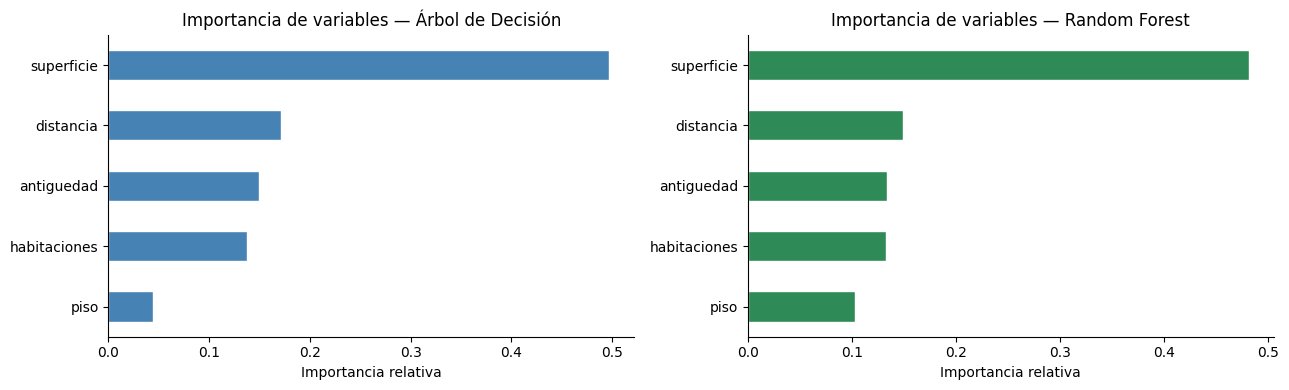

In [20]:
# Importancia de variables — Random Forest
importancias_rf = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, imp, titulo, color in [
    (axes[0], importancias,    'Árbol de Decisión', 'steelblue'),
    (axes[1], importancias_rf, 'Random Forest',     'seagreen')
]:
    imp.plot(kind='barh', color=color, edgecolor='white', ax=ax)
    ax.set_title(f'Importancia de variables — {titulo}')
    ax.set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

---

## 7. Validación Cruzada

El split train/test depende del azar: con mala suerte, el test set puede ser atípico y dar una estimación sesgada del rendimiento real. La **validación cruzada** (cross-validation) resuelve esto dividiendo los datos en $k$ partes y repitiendo el proceso $k$ veces, usando cada parte como test set una vez.

<!-- IMAGEN SUGERIDA: diagrama de k-fold cross validation mostrando las k iteraciones, con el fold de test destacado en cada una y el promedio final. -->

In [21]:
modelos_cv = {
    'Regresión Lineal': LinearRegression(),
    'Ridge':            Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'Lasso':            Pipeline([('s', StandardScaler()), ('m', Lasso(alpha=10_000))]),
    'Árbol (depth=5)':  DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':    RandomForestRegressor(n_estimators=100, max_depth=8,
                                              random_state=42, n_jobs=-1),
}

print(f"{'Modelo':<25} {'R² CV medio':>12} {'Std':>8}")
print("-" * 48)

cv_resultados = {}
for nombre, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_resultados[nombre] = scores
    print(f"{nombre:<25} {scores.mean():>12.4f} {scores.std():>8.4f}")

Modelo                     R² CV medio      Std
------------------------------------------------
Regresión Lineal                0.5413   0.0286
Ridge                           0.5415   0.0282
Lasso                           0.5414   0.0279
Árbol (depth=5)                 0.2123   0.1759
Random Forest                   0.5121   0.0339


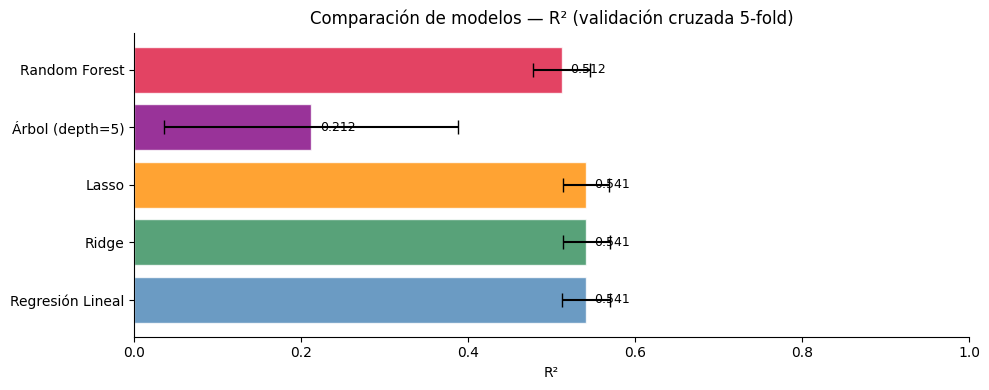

In [22]:
# Visualización comparativa de CV
fig, ax = plt.subplots(figsize=(10, 4))

nombres = list(cv_resultados.keys())
medias  = [cv_resultados[n].mean() for n in nombres]
stds    = [cv_resultados[n].std()  for n in nombres]
colores = ['steelblue', 'seagreen', 'darkorange', 'purple', 'crimson']

bars = ax.barh(nombres, medias, xerr=stds, color=colores,
               edgecolor='white', alpha=0.8, capsize=5)
ax.set_title('Comparación de modelos — R² (validación cruzada 5-fold)')
ax.set_xlabel('R²')
ax.set_xlim(0, 1)

for bar, media in zip(bars, medias):
    ax.text(media + 0.01, bar.get_y() + bar.get_height()/2,
            f'{media:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---

## 8. Comparación Final de Modelos

Reunimos todas las métricas en una tabla para elegir el modelo más adecuado.

In [23]:
# Tabla resumen con todas las métricas en test set
df_resultados = pd.DataFrame(resultados).set_index('modelo')
df_resultados['MAE'] = df_resultados['MAE'].map('{:,.0f}'.format)
df_resultados['RMSE'] = df_resultados['RMSE'].map('{:,.0f}'.format)
df_resultados['R2'] = df_resultados['R2'].round(4)
print("=== Métricas en Test Set ===")
print(df_resultados.to_string())

=== Métricas en Test Set ===
                       MAE       RMSE      R2
modelo                                       
Ridge (α=1)      2,269,176  2,809,115  0.4477
Lasso (α=10k)    2,271,211  2,810,849  0.4470
Árbol (depth=5)  3,109,279  3,733,845  0.0241
Random Forest    2,413,785  2,947,508  0.3919


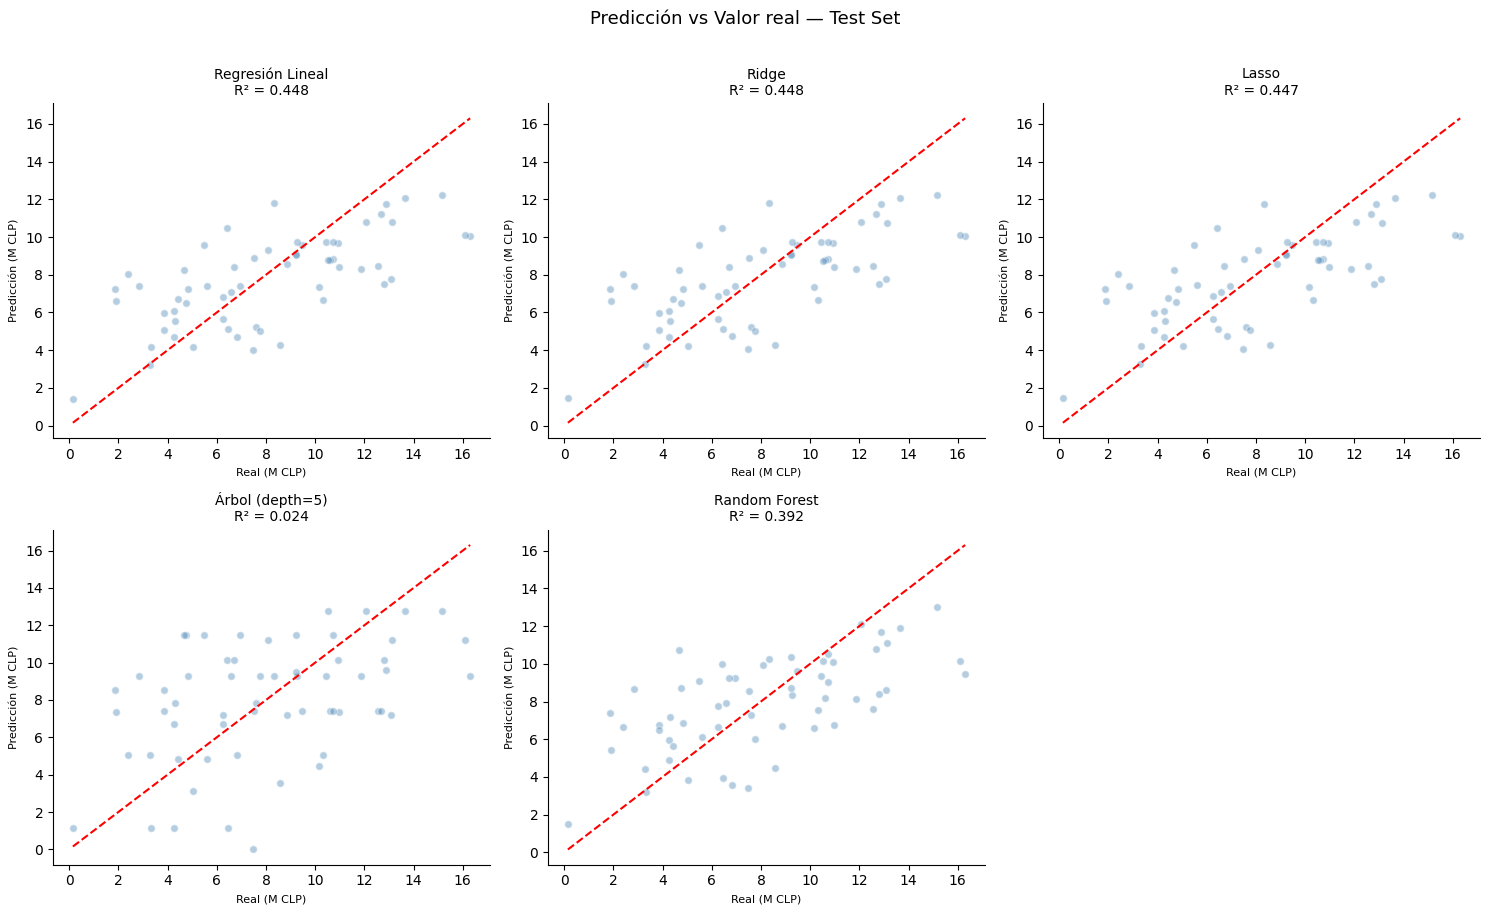

In [24]:
# Visualización: predicción vs real para todos los modelos
modelos_pred = {
    'Regresión Lineal': y_pred_lr,
    'Ridge':            y_pred_ridge,
    'Lasso':            y_pred_lasso,
    'Árbol (depth=5)':  y_pred_tree,
    'Random Forest':    y_pred_rf,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

lim_low  = y_test.min() / 1e6
lim_high = y_test.max() / 1e6

for ax, (nombre, y_pred) in zip(axes, modelos_pred.items()):
    r2 = r2_score(y_test, y_pred)
    ax.scatter(y_test/1e6, y_pred/1e6, alpha=0.4, s=30,
               color='steelblue', edgecolor='white')
    ax.plot([lim_low, lim_high], [lim_low, lim_high],
            'r--', lw=1.5)
    ax.set_title(f'{nombre}\nR² = {r2:.3f}', fontsize=10)
    ax.set_xlabel('Real (M CLP)', fontsize=8)
    ax.set_ylabel('Predicción (M CLP)', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Predicción vs Valor real — Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()



## Resumen

| Modelo | Fortaleza | Limitación |
|---|---|---|
| **Regresión Lineal** | Simple, interpretable, base de comparación | Asume relación lineal |
| **Ridge** | Estable con multicolinealidad | No elimina variables |
| **Lasso** | Selección implícita de variables | Inestable con predictores muy correlacionados |
| **Árbol de Decisión** | Flexible, captura no linealidades | Muy propenso a overfitting |
| **Random Forest** | Robusto, buen rendimiento general | Menos interpretable, más lento |

**Ideas clave:**
- Siempre evaluar en **test set**, nunca en train
- Usar **validación cruzada** para estimaciones más estables del rendimiento
- Ridge y Lasso requieren **escalar las features** (el árbol y Random Forest no)
- El gráfico de predicción vs real es tan informativo como cualquier métrica
- Un R² alto en train con R² bajo en test es la señal clásica de overfitting



## Referencias

1. James, G., Witten, D., Hastie, T., Tibshirani, R. (2021). *An Introduction to Statistical Learning*. Springer. Cap. 3 y 6.
2. Scikit-learn — Linear Models: [https://scikit-learn.org/stable/modules/linear_model.html](https://scikit-learn.org/stable/modules/linear_model.html)
3. Scikit-learn — Model Evaluation: [https://scikit-learn.org/stable/modules/model_evaluation.html](https://scikit-learn.org/stable/modules/model_evaluation.html)